# 02 — Firm-year analysis of `general_2016_2018.csv`

Follows on from `01-explore.ipynb`, which eyeballed the raw extract.

All logic lives in `src/`; this notebook only calls it:

| module | what it provides |
|---|---|
| `src.load` | read -> validate -> clean |
| `src.aggregate` | the (auditor firm, audit year) grain |
| `src.charts` | ranked bar panels per year |

## Load

`load_clean` runs the schema validation first, so nothing below executes
against an extract that fails `GeneralSchema`.

In [5]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

from src.load import load_clean

df, dropped = load_clean(ROOT / "data" / "general_2016_2018.csv")
print(f"{len(df):,} rows x {df.shape[1]} cols; dropped {dropped}")
df.head()

110,948 rows x 59 cols; dropped ['auditor_country', 'auditor_foreign_address', 'type_audit_code', 'is_additional_ueis', 'resubmission_status']


,report_id,auditee_uei,audit_year,auditee_certify_name,auditee_certify_title,auditee_contact_name,auditee_email,auditee_name,auditee_phone,auditee_contact_title,...,entity_type,number_months,audit_period_covered,total_amount_expended,is_public,data_source,is_aicpa_audit_guide_included,resubmission_version,is_multiple_eins,is_secondary_auditors
0,2018-12-GSAFAC-0000002490,MX6LJJSB1J94,2018,Vicki Horst,City Auditor,VICKI HORST,glenullinauditor@midconetwork.com,CITY OF GLEN ULLIN,7013483683,AUDITOR,...,local,NaN,annual,4438138.0,True,GSAFAC,False,0,False,False
1,2018-12-GSAFAC-0000005590,EX78LVMAM154,2018,Michael Akins,DIrector of Finance,Michael Akins,michael.akins@eurekaspringsar.gov,"City of Eureka Springs, Arkansas",4792539703,Finance Director,...,local,NaN,annual,777402.0,True,GSAFAC,False,0,False,False
2,2018-12-GSAFAC-0000011259,HRAATANFJ7C3,2018,ROXANA VALETON,CEO,Roxana Valeton,rvaleton@firstpersonclinic.org,"First Person Care Clinic, Inc.",7023808118,CEO,...,non-profit,NaN,annual,794158.0,True,GSAFAC,False,0,False,False
3,2017-06-GSAFAC-0000011277,E1N5H91U1WJ9,2017,Lori Sughroue,Auditee certification,Alan Sylvester,AlanS@lmc-mi.com,Country View Apartments,2693502013,Managing Agent,...,non-profit,NaN,annual,1318575.0,True,GSAFAC,False,0,False,False
4,2017-09-GSAFAC-0000015611,F3VGS7CZWE25,2017,Felicia Jackson,Executive Director,FELICIA JACKSON,FELICIA@ARCHCONNECTION.ORG,ALABAMA RURAL COALITION FOR THE HOMELESS INC,3342730668,EXECUTIVE DIRECTOR,...,non-profit,NaN,annual,2240281.0,True,GSAFAC,True,0,False,False


## Top audit firms per year

Aggregation from `src/aggregate.py`, plotting from `src/charts.py` — the
notebook only calls them.

Note the frame above came from `load_clean`, which maps the `GSA_MIGRATION`
sentinel to NA. That is why `auditees_per_firm_year` counts distinct
`auditee_ein` rather than `auditee_uei`: the UEI column is the placeholder on
99.97% of rows, so a distinct count over it collapses to 1 for almost every
firm-year.

In [6]:
from src.aggregate import auditees_per_firm_year, summarise_by_firm_year

per_year = auditees_per_firm_year(df)
print(f"{len(per_year):,} firm-years")
per_year.head(10)

22,478 firm-years


,auditor_firm_name,audit_year,n_auditees
0,CLIFTONLARSONALLEN LLP,2018,846
1,CLIFTONLARSONALLEN LLP,2017,716
2,CLIFTONLARSONALLEN LLP,2016,608
3,"PLANTE & MORAN, PLLC",2018,547
4,"PLANTE & MORAN, PLLC",2017,535
5,"PLANTE & MORAN, PLLC",2016,496
6,RSM US LLP,2016,455
7,"BKD, LLP",2018,443
8,RSM US LLP,2017,442
9,"DAUBY O'CONNOR & ZALESKI, LLC",2018,435


In [7]:
# the wide view: distinct-value counts for every column, per firm-year
summary = summarise_by_firm_year(df)
print(f"{summary.shape[0]:,} firm-years x {summary.shape[1]} columns")

cols = ["auditor_firm_name", "audit_year", "n_rows", "auditee_ein", "auditee_state", "entity_type"]
summary.nlargest(10, "n_rows")[cols]

22,478 firm-years x 60 columns


,auditor_firm_name,audit_year,n_rows,auditee_ein,auditee_state,entity_type
4405,CLIFTONLARSONALLEN LLP,2018,853,846,44,6
4404,CLIFTONLARSONALLEN LLP,2017,721,716,40,6
4403,CLIFTONLARSONALLEN LLP,2016,614,608,38,6
16361,"PLANTE & MORAN, PLLC",2018,551,547,15,4
16360,"PLANTE & MORAN, PLLC",2017,538,535,11,5
16359,"PLANTE & MORAN, PLLC",2016,496,496,11,4
18142,RSM US LLP,2016,466,455,37,5
18143,RSM US LLP,2017,454,442,34,6
2218,"BKD, LLP",2018,445,443,40,6
5392,"DAUBY O'CONNOR & ZALESKI, LLC",2018,437,435,20,2


## Chart

One panel per audit year, ranked largest to smallest. Panels share a y-scale
so bar heights compare across years; each panel is ranked independently, so
the firms shown may differ between panels.

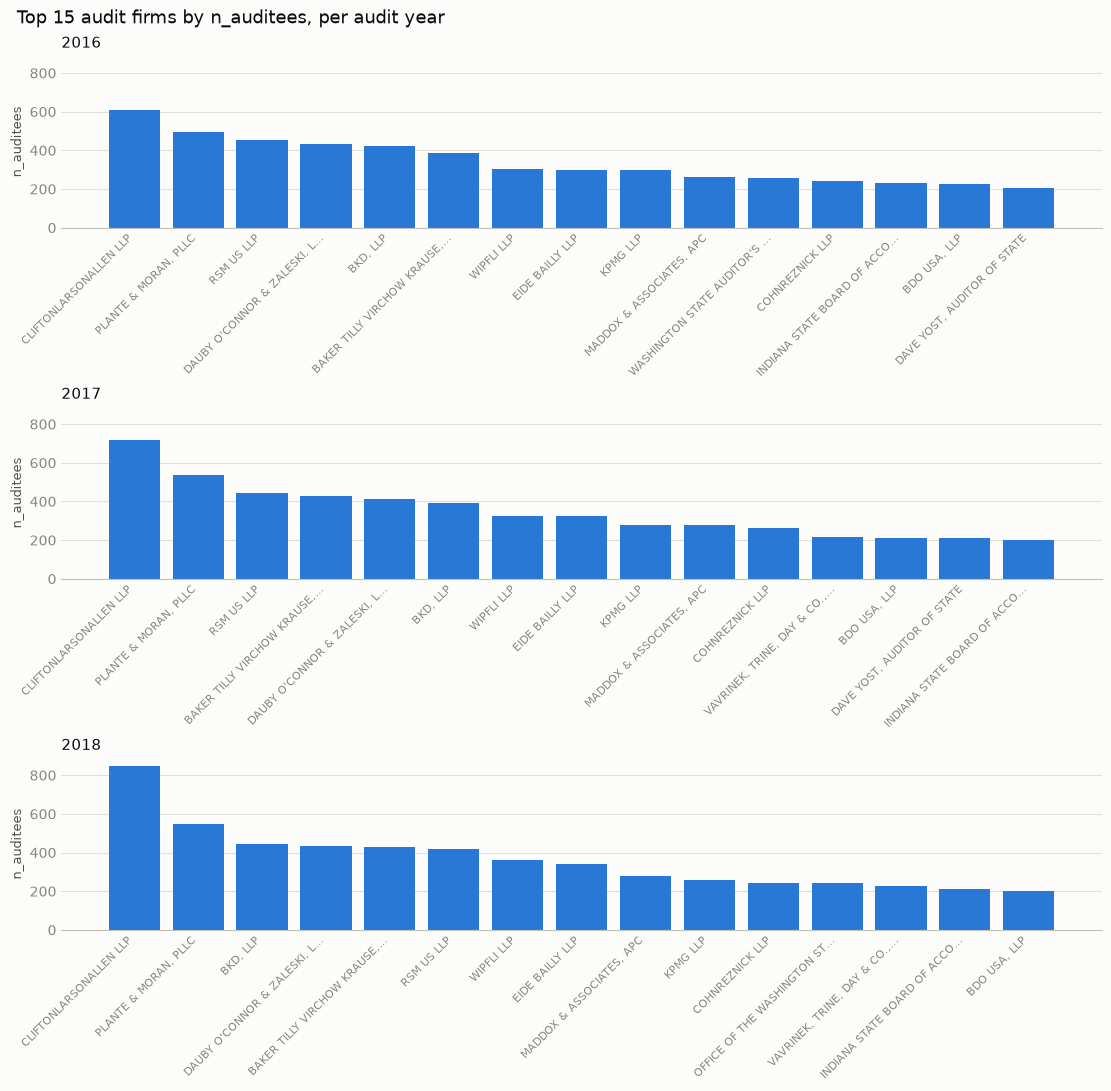

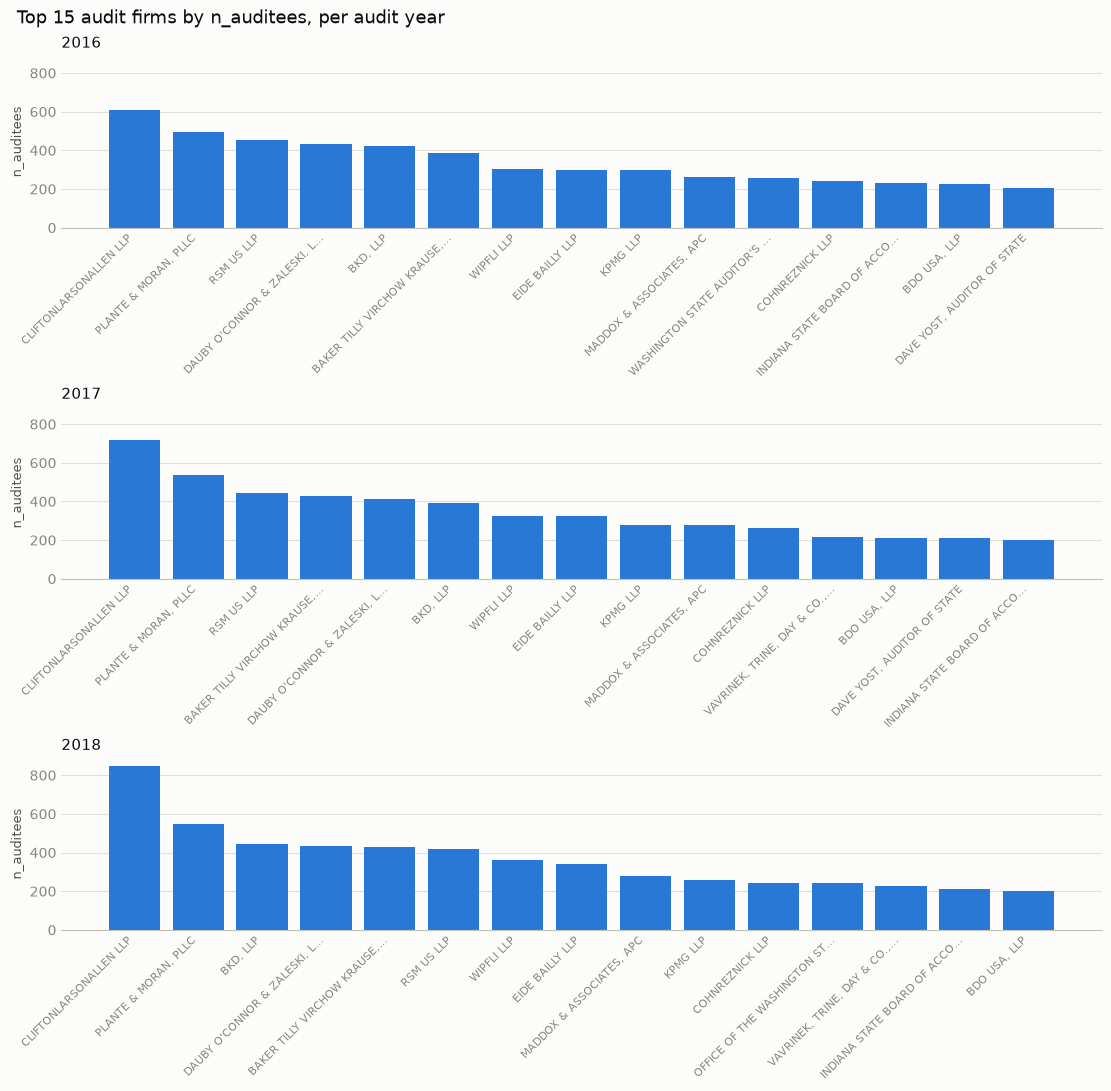

In [8]:
from src.charts import plot_firms_by_year

fig = plot_firms_by_year(
    per_year,
    value_column="n_auditees",
    top_n=15,
    output_path=ROOT / "reports" / "top_firms_by_year.png",
)
fig

## Scratch